Datos de entrenamiento listos. Listos para los modelos de regresión.


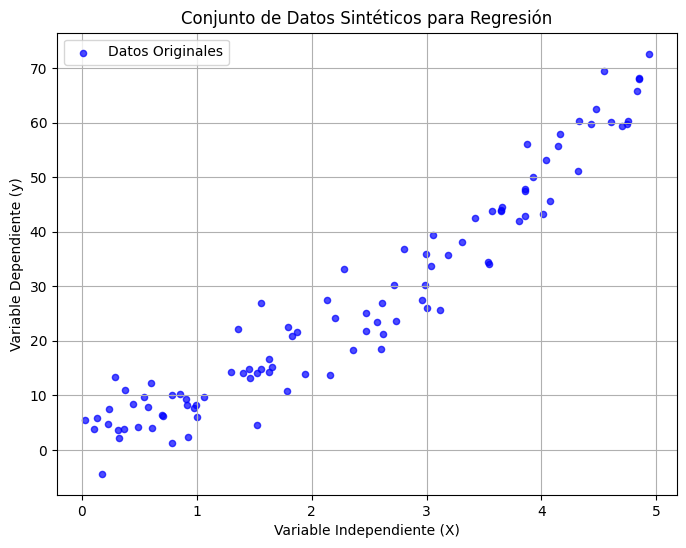

In [ ]:
# Clase 29/07 Sesión 4 módulo 6
# 1. Importar Librerías
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split # Para dividir datos

# 2. Creación de un Dataset de Ejemplo para Regresión
# Generamos datos sintéticos con una relación no lineal (similar a una parábola o una curva)
np.random.seed(42) # Para reproducibilidad de los resultados

# Generar 100 puntos de datos para X
X = np.sort(5 * np.random.rand(100, 1), axis=0)
# Generar Y con una relación cuadrática y añadir algo de ruido
y = 2 * X**2 + 3 * X + 5 + np.random.randn(100, 1) * 5

# Dividir los datos en conjuntos de entrenamiento y prueba
# Usamos un 80% para entrenamiento y un 20% para prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Datos de entrenamiento listos. Listos para los modelos de regresión.")

# Visualizar los datos originales (opcional, para entender la distribución)
plt.figure(figsize=(8, 6))
plt.scatter(X, y, s=20, alpha=0.7, color='blue', label='Datos Originales')
plt.xlabel("Variable Independiente (X)")
plt.ylabel("Variable Dependiente (y)")
plt.title("Conjunto de Datos Sintéticos para Regresión")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# 3. Regresión Lineal Simple
print("\n--- Modelo de Regresión Lineal ---")

# Crear una instancia del modelo de Regresión Lineal
model_lin = LinearRegression()

# Entrenar el modelo con los datos de entrenamiento
model_lin.fit(X_train, y_train)

# Hacer predicciones en el conjunto de prueba
y_pred_lin = model_lin.predict(X_test)

# Calcular el Error Cuadrático Medio (MSE) para la regresión lineal
error_lin = mean_squared_error(y_test, y_pred_lin)
print(f"Error Cuadrático Medio (MSE) - Regresión Lineal: {error_lin:.2f}")


--- Modelo de Regresión Lineal ---
Error Cuadrático Medio (MSE) - Regresión Lineal: 31.22


In [ ]:
# 4. Regresión Polinómica (Grado 2 en este ejemplo)
print("\n--- Modelo de Regresión Polinómica ---")

# Definir el grado del polinomio (ej. 2 para una parábola)
polynomial_degree = 2

# Crear características polinómicas
# PolynomialFeatures transforma las características X en X^1, X^2, etc.
poly_features = PolynomialFeatures(degree=polynomial_degree)
X_train_poly = poly_features.fit_transform(X_train)
X_test_poly = poly_features.transform(X_test) # Importante: solo transform, no fit_transform en test

# Crear una instancia del modelo de Regresión Lineal (que ahora operará sobre las características polinómicas)
model_poly = LinearRegression()

# Entrenar el modelo con las características polinómicas
model_poly.fit(X_train_poly, y_train)

# Hacer predicciones en el conjunto de prueba con las características polinómicas
y_pred_poly = model_poly.predict(X_test_poly)

# Calcular el Error Cuadrático Medio (MSE) para la regresión polinómica
error_poly = mean_squared_error(y_test, y_pred_poly)
print(f"Error Cuadrático Medio (MSE) - Regresión Polinómica: {error_poly:.2f}")


--- Modelo de Regresión Polinómica ---
Error Cuadrático Medio (MSE) - Regresión Polinómica: 17.34


In [ ]:
# 5. Árbol de Decisión para Regresión
print("\n--- Modelo de Árbol de Decisión para Regresión ---")

# Crear una instancia del modelo de Árbol de Decisión para Regresión
# random_state asegura reproducibilidad
# max_depth limita la profundidad del árbol para evitar sobreajuste extremo en este ejemplo
model_tree = DecisionTreeRegressor(random_state=42, max_depth=5)
# DecisionTreeRegressor es el modelo de Scikit-learn.
# random_state=42 garantiza que los resultados sean siempre los mismos (reproducibilidad).
# max_depth=5 limita la profundidad del árbol a 5 niveles para evitar que el modelo se sobreentrene (sobreajuste).


# Entrenar el modelo con los datos de entrenamiento
model_tree.fit(X_train, y_train)

# Hacer predicciones en el conjunto de prueba
y_pred_tree = model_tree.predict(X_test)

# Calcular el Error Cuadrático Medio (MSE) para el árbol de decisión
error_tree = mean_squared_error(y_test, y_pred_tree)
print(f"Error Cuadrático Medio (MSE) - Árbol de Decisión: {error_tree:.2f}")



--- Modelo de Árbol de Decisión para Regresión ---
Error Cuadrático Medio (MSE) - Árbol de Decisión: 18.68


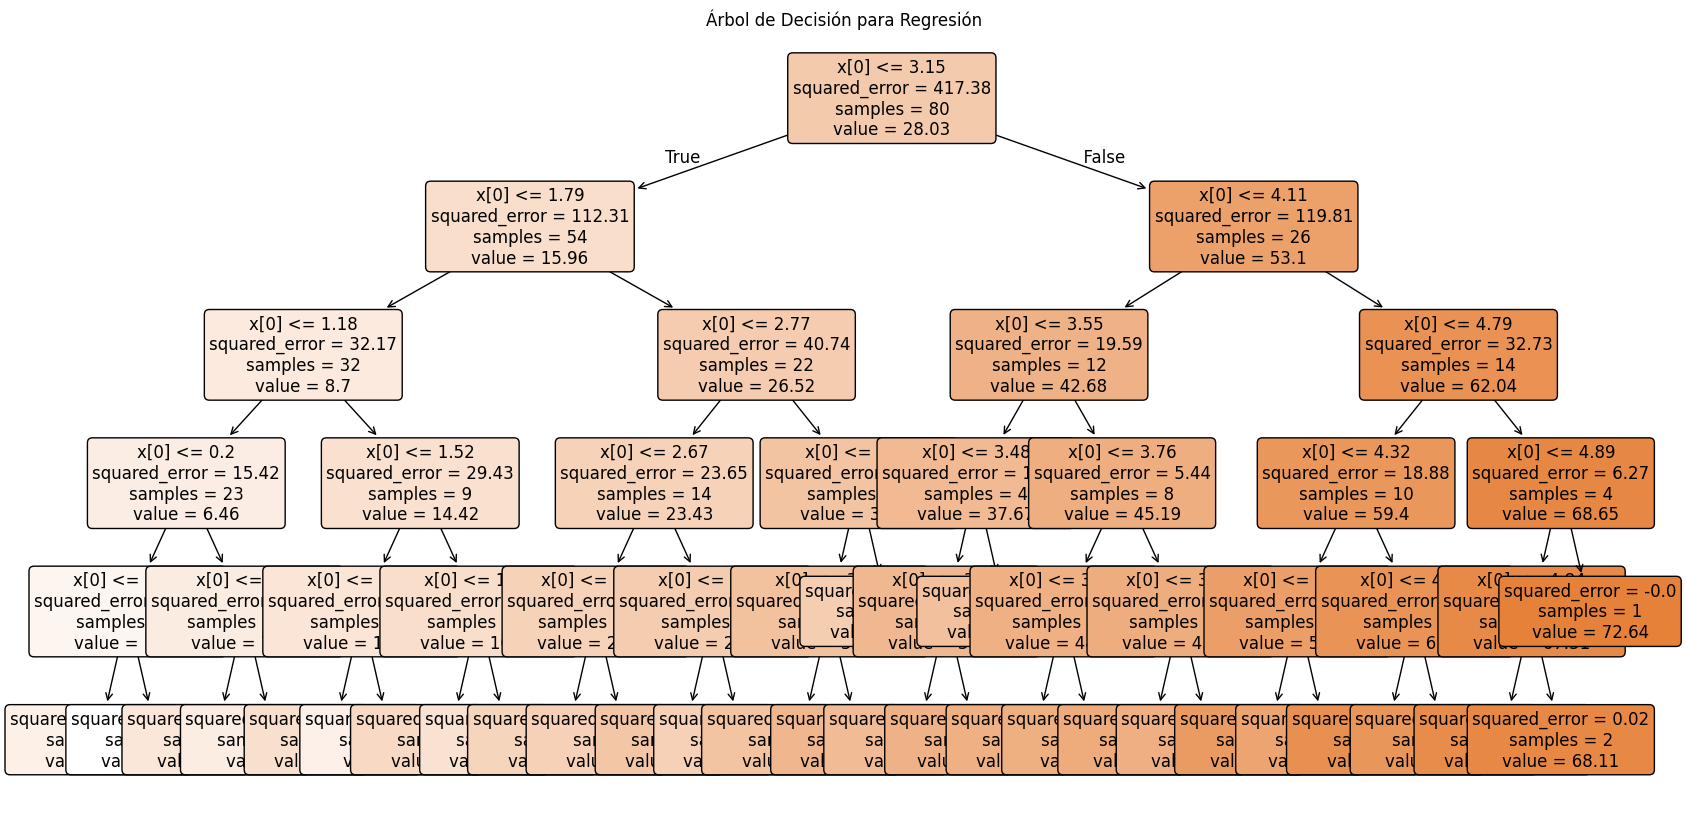

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(
    model_tree,
    filled=True,
    rounded=True,
    precision=2,
    fontsize=12
)
plt.title("Árbol de Decisión para Regresión")
plt.show()
# Cada cuadro (nodo) tiene varios elementos:
# x[0] <= valor: condición para dividir los datos. x[0] indica la primera variable usada como criterio de decisión.
# squared_error: el error cuadrático medio dentro del nodo (medida de impureza).
# samples: cuántos datos hay en ese nodo.
# value: promedio de la variable objetivo en ese nodo (valor que predice el modelo si se llega hasta ahí).

# Raíz del árbol (top):
# Primera división: x[0] <= 3.15. Se divide el conjunto total (80 muestras) en dos ramas: izquierda (sí cumple) y derecha (no cumple).
# Valor promedio del target (por ejemplo, ingreso estimado) es 28.03.

# Hojas del árbol (bottom):
# Son los nodos finales. Por ejemplo, un nodo con:
# samples = 2
# value = 68.11

# predice que para esos dos registros, el valor estimado es 68.11.

# ¿Por qué hay nodos anaranjados más oscuros?
# El color representa el valor de salida:

# Cuanto más oscuro, mayor es el valor estimado (value).

# Los colores ayudan a visualizar rápidamente las zonas de valores bajos y altos.
# ¿Qué te permite hacer este modelo?
# Estimar un valor continuo basado en condiciones simples del tipo "si X es menor o mayor a cierto umbral".
# Útil cuando no hay una relación lineal clara entre las variables.



--- Comparación Visual de Modelos ---


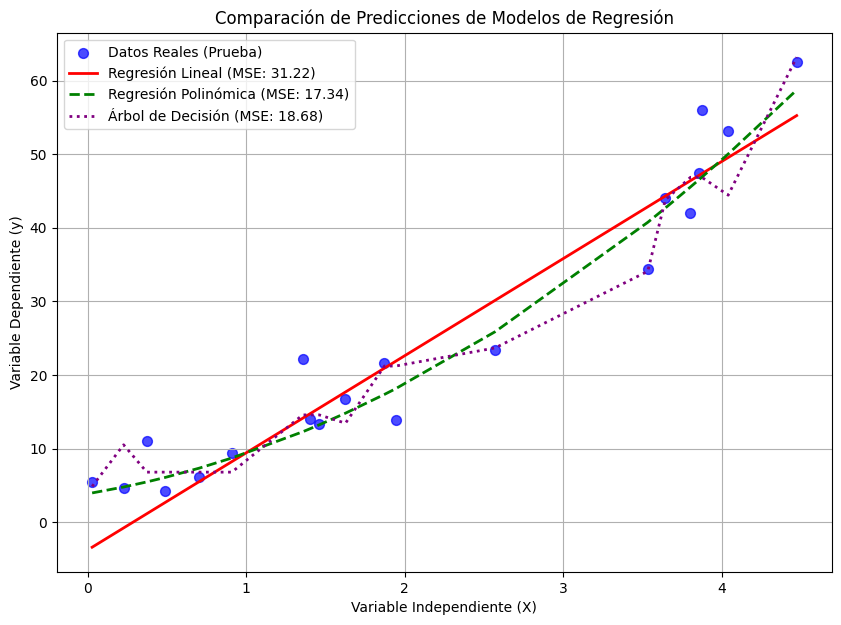

In [ ]:
# 6. Visualización y Comparación de Modelos
print("\n--- Comparación Visual de Modelos ---")

plt.figure(figsize=(10, 7))

# Graficar los datos de prueba reales
plt.scatter(X_test, y_test, color='blue', label='Datos Reales (Prueba)', alpha=0.7, s=50)
# Dibuja los datos reales (X_test, y_test) como puntos dispersos (scatter plot), en color azul:
# alpha=0.7: da un poco de transparencia.
# s=50: tamaño de los puntos.

# Graficar las predicciones de cada modelo
# Ordenar X_test para que las líneas de predicción se vean correctas si el modelo predice un continuo
X_test_sorted, y_pred_lin_sorted = zip(*sorted(zip(X_test.flatten(), y_pred_lin.flatten())))
X_test_sorted, y_pred_poly_sorted = zip(*sorted(zip(X_test.flatten(), y_pred_poly.flatten())))
X_test_sorted, y_pred_tree_sorted = zip(*sorted(zip(X_test.flatten(), y_pred_tree.flatten())))
# .flatten() convierte arreglos 2D en 1D para facilitar la ordenación.
# zip(*sorted(...)) devuelve dos listas ordenadas paralelas: X ordenado y su correspondiente y ordenada.


plt.plot(X_test_sorted, y_pred_lin_sorted, color='red', linestyle='-', linewidth=2, label=f'Regresión Lineal (MSE: {error_lin:.2f})')
plt.plot(X_test_sorted, y_pred_poly_sorted, color='green', linestyle='--', linewidth=2, label=f'Regresión Polinómica (MSE: {error_poly:.2f})')
plt.plot(X_test_sorted, y_pred_tree_sorted, color='purple', linestyle=':', linewidth=2, label=f'Árbol de Decisión (MSE: {error_tree:.2f})')


plt.xlabel("Variable Independiente (X)")
plt.ylabel("Variable Dependiente (y)")
plt.title("Comparación de Predicciones de Modelos de Regresión")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# 7. Selección del Mejor Modelo (basado en MSE)
print("\n--- Selección del Mejor Modelo ---")
errores = {
    "Regresión Lineal": error_lin,
    "Regresión Polinómica": error_poly,
    "Árbol de Decisión": error_tree
}

# Encontrar el modelo con el MSE más bajo
best_model_name = min(errores, key=errores.get)
min_mse = errores[best_model_name]

print(f"El modelo con el menor Error Cuadrático Medio (MSE) es: '{best_model_name}' con un MSE de {min_mse:.2f}")


--- Selección del Mejor Modelo ---
El modelo con el menor Error Cuadrático Medio (MSE) es: 'Regresión Polinómica' con un MSE de 17.34


In [ ]:
# Regresión Ridge y Lasso (Regularización)
# Regresión de Soporte Vectorial (SVR)
# Cálculo de R² y MAE (además del MSE que ya teníamos)
# Importar librerías adicionales para esta sección
from sklearn.linear_model import Ridge, Lasso
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error

# --- Reutilizamos los datos generados en la sección anterior ---
# Asegúrate de que X_train, X_test, y_train, y_test estén definidos.
# Si estás ejecutando esto por separado, puedes volver a generarlos así:
# import numpy as np
# from sklearn.model_selection import train_test_split
# X = np.sort(5 * np.random.rand(100, 1), axis=0)
# y = 2 * X**2 + 3 * X + 5 + np.random.randn(100, 1) * 5
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Datos de entrenamiento y prueba listos para modelos adicionales.")

Datos de entrenamiento y prueba listos para modelos adicionales.


In [ ]:
# Regresión Ridge (con Regularización L2)
# Ridge Regression es una forma de regresión lineal que añade una penalización a la función de costo para reducir
# la magnitud de los coeficientes del modelo. Esto ayuda a prevenir el sobreajuste (overfitting), especialmente cuando hay multicolinealidad.
# 1. Regresión Ridge
print("\n--- Modelo de Regresión Ridge ---")

# Crear una instancia del modelo Ridge
# El parámetro 'alpha' controla la fuerza de la regularización.
# Un 'alpha' más grande significa más regularización.
model_ridge = Ridge(alpha=1.0, random_state=42)

# Entrenar el modelo con los datos de entrenamiento
model_ridge.fit(X_train, y_train)

# Hacer predicciones en el conjunto de prueba
y_pred_ridge = model_ridge.predict(X_test)

# Calcular métricas de evaluación
error_ridge_mse = mean_squared_error(y_test, y_pred_ridge)
error_ridge_mae = mean_absolute_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print(f"Error Cuadrático Medio (MSE) - Regresión Ridge: {error_ridge_mse:.2f}")
print(f"Error Absoluto Medio (MAE) - Regresión Ridge: {error_ridge_mae:.2f}")
print(f"Coeficiente de Determinación (R²) - Regresión Ridge: {r2_ridge:.2f}")

# Nota: Para una Regresión Polinómica con Ridge/Lasso, primero aplicarías PolynomialFeatures
# y luego entrenarías Ridge/Lasso sobre las características transformadas.


--- Modelo de Regresión Ridge ---
Error Cuadrático Medio (MSE) - Regresión Ridge: 30.91
Error Absoluto Medio (MAE) - Regresión Ridge: 4.38
Coeficiente de Determinación (R²) - Regresión Ridge: 0.91


In [ ]:
# Regresión Lasso (con Regularización L1)
# Lasso Regression también añade una penalización, pero esta vez a la suma de los valores absolutos de los
# coeficientes (penalización L1). Esto no solo reduce la magnitud de los coeficientes, sino que también puede llevar
# a que algunos coeficientes se vuelvan cero, lo que permite la selección de características automáticamente.
# 2. Regresión Lasso
print("\n--- Modelo de Regresión Lasso ---")

# Crear una instancia del modelo Lasso
# 'alpha' también controla la fuerza de la regularización.
# Un 'alpha' más grande puede llevar a más coeficientes a cero.
model_lasso = Lasso(alpha=0.1, random_state=42, max_iter=10000) # Aumentar max_iter si no converge

# Entrenar el modelo con los datos de entrenamiento
model_lasso.fit(X_train, y_train)

# Hacer predicciones en el conjunto de prueba
y_pred_lasso = model_lasso.predict(X_test)

# Calcular métricas de evaluación
error_lasso_mse = mean_squared_error(y_test, y_pred_lasso)
error_lasso_mae = mean_absolute_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print(f"Error Cuadrático Medio (MSE) - Regresión Lasso: {error_lasso_mse:.2f}")
print(f"Error Absoluto Medio (MAE) - Regresión Lasso: {error_lasso_mae:.2f}")
print(f"Coeficiente de Determinación (R²) - Regresión Lasso: {r2_lasso:.2f}")


--- Modelo de Regresión Lasso ---
Error Cuadrático Medio (MSE) - Regresión Lasso: 31.03
Error Absoluto Medio (MAE) - Regresión Lasso: 4.39
Coeficiente de Determinación (R²) - Regresión Lasso: 0.91


In [ ]:
# Regresión de Soporte Vectorial (SVR)
# SVR es una extensión de las Máquinas de Soporte Vectorial (SVM) para problemas de regresión. Es un modelo potente
# para relaciones no lineales y puede manejar datos de alta dimensionalidad. Permite especificar un margen de tolerancia (epsilon)
# dentro del cual los errores no son penalizados.
# 3. Regresión de Soporte Vectorial (SVR)
print("\n--- Modelo de Regresión de Soporte Vectorial (SVR) ---")

# Crear una instancia del modelo SVR
# kernel='rbf' (Radial Basis Function) es común para relaciones no lineales.
# C: Parámetro de regularización. Un C más alto significa menos regularización (más ajuste a los datos).
# epsilon: Margen de tolerancia donde no se penalizan los errores.
model_svr = SVR(kernel='rbf', C=100, epsilon=0.1) # Ajustar C y epsilon según los datos

# Entrenar el modelo con los datos de entrenamiento
# SVR suele beneficiarse del escalado de datos, aunque para este ejemplo simple no es estrictamente necesario.
# Si tus datos fueran muy variados en escala, usarías StandardScaler o MinMaxScaler antes de SVR.
model_svr.fit(X_train.flatten().reshape(-1, 1), y_train.flatten()) # SVR espera 1D para y_train si X_train es 2D

# Hacer predicciones en el conjunto de prueba
y_pred_svr = model_svr.predict(X_test.flatten().reshape(-1, 1))

# Calcular métricas de evaluación
error_svr_mse = mean_squared_error(y_test, y_pred_svr)
error_svr_mae = mean_absolute_error(y_test, y_pred_svr)
r2_svr = r2_score(y_test, y_pred_svr)

print(f"Error Cuadrático Medio (MSE) - SVR: {error_svr_mse:.2f}")
print(f"Error Absoluto Medio (MAE) - SVR: {error_svr_mae:.2f}")
print(f"Coeficiente de Determinación (R²) - SVR: {r2_svr:.2f}")


--- Modelo de Regresión de Soporte Vectorial (SVR) ---
Error Cuadrático Medio (MSE) - SVR: 16.23
Error Absoluto Medio (MAE) - SVR: 2.86
Coeficiente de Determinación (R²) - SVR: 0.95


Librerías importadas y listas.
Datos de entrenamiento y prueba generados y divididos.


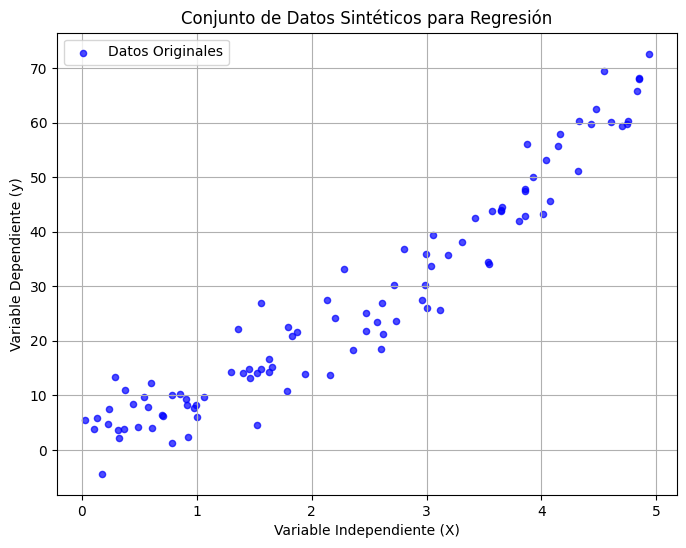


--- Modelo de Regresión Lineal ---
Error Cuadrático Medio (MSE) - Regresión Lineal: 31.22
Error Absoluto Medio (MAE) - Regresión Lineal: 4.41
Coeficiente de Determinación (R²) - Regresión Lineal: 0.91

--- Modelo de Regresión Polinómica ---
Error Cuadrático Medio (MSE) - Regresión Polinómica: 17.34
Error Absoluto Medio (MAE) - Regresión Polinómica: 3.16
Coeficiente de Determinación (R²) - Regresión Polinómica: 0.95

--- Modelo de Árbol de Decisión para Regresión ---
Error Cuadrático Medio (MSE) - Árbol de Decisión: 18.68
Error Absoluto Medio (MAE) - Árbol de Decisión: 3.08
Coeficiente de Determinación (R²) - Árbol de Decisión: 0.95

--- Modelo de Regresión Ridge ---
Error Cuadrático Medio (MSE) - Regresión Ridge: 30.91
Error Absoluto Medio (MAE) - Regresión Ridge: 4.38
Coeficiente de Determinación (R²) - Regresión Ridge: 0.91

--- Modelo de Regresión Lasso ---
Error Cuadrático Medio (MSE) - Regresión Lasso: 31.03
Error Absoluto Medio (MAE) - Regresión Lasso: 4.39
Coeficiente de Determ

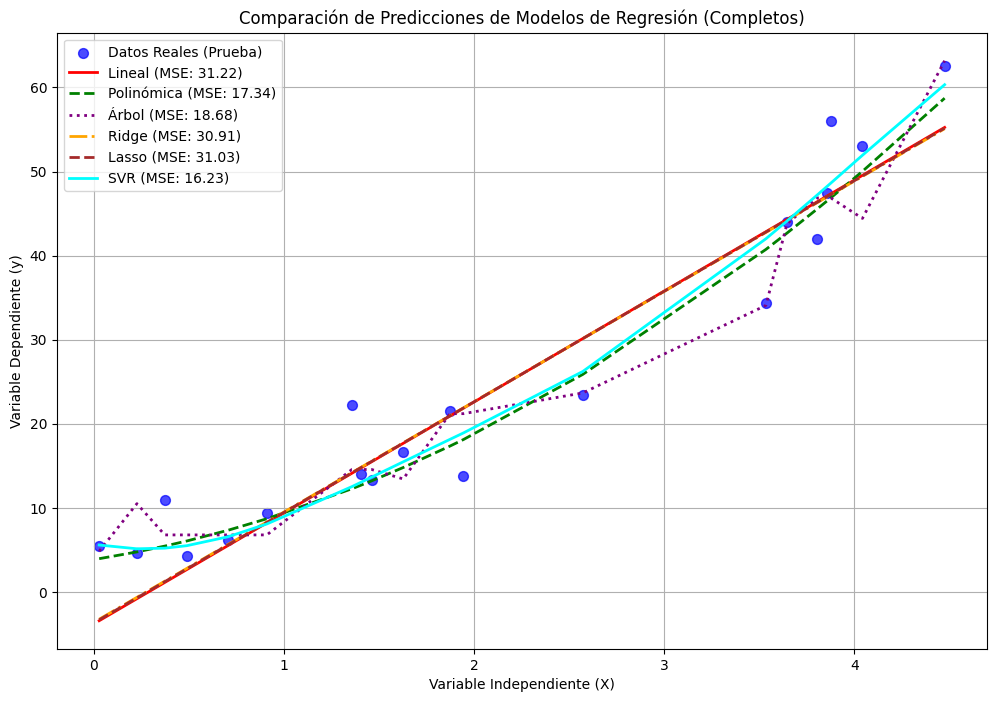


--- Resumen de Métricas de Evaluación para todos los Modelos ---

Modelo: Regresión Lineal
  MSE: 31.22
  MAE: 4.41
  R²: 0.91

Modelo: Regresión Polinómica
  MSE: 17.34
  MAE: 3.16
  R²: 0.95

Modelo: Árbol de Decisión
  MSE: 18.68
  MAE: 3.08
  R²: 0.95

Modelo: Regresión Ridge
  MSE: 30.91
  MAE: 4.38
  R²: 0.91

Modelo: Regresión Lasso
  MSE: 31.03
  MAE: 4.39
  R²: 0.91

Modelo: Regresión SVR
  MSE: 16.23
  MAE: 2.86
  R²: 0.95

El modelo con el menor MSE es: 'Regresión SVR'
El modelo con el mayor R² es: 'Regresión SVR'


In [ ]:
# Visualización y Comparación (Actualizada con nuevos modelos)
# Ahora, podemos añadir las predicciones de los nuevos modelos al gráfico comparativo.
# 4. Visualización y Comparación de Todos los Modelos
# 4. Visualización y Comparación de TODOS los Modelos
# --- 1. Preparación de Datos y Librerías ---
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR # Importamos SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score # Importamos todas las métricas
from sklearn.model_selection import train_test_split

print("Librerías importadas y listas.")

# Creación de un Dataset de Ejemplo para Regresión
np.random.seed(42)
X = np.sort(5 * np.random.rand(100, 1), axis=0)
y = 2 * X**2 + 3 * X + 5 + np.random.randn(100, 1) * 5 # Relación cuadrática con ruido

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Datos de entrenamiento y prueba generados y divididos.")

# Visualizar los datos originales
plt.figure(figsize=(8, 6))
plt.scatter(X, y, s=20, alpha=0.7, color='blue', label='Datos Originales')
plt.xlabel("Variable Independiente (X)")
plt.ylabel("Variable Dependiente (y)")
plt.title("Conjunto de Datos Sintéticos para Regresión")
plt.legend()
plt.grid(True)
plt.show()

# --- 2. Regresión Lineal Simple ---
print("\n--- Modelo de Regresión Lineal ---")
model_lin = LinearRegression()
model_lin.fit(X_train, y_train)
y_pred_lin = model_lin.predict(X_test)

# Calcular métricas para Regresión Lineal
error_lin_mse = mean_squared_error(y_test, y_pred_lin)
error_lin_mae = mean_absolute_error(y_test, y_pred_lin)
r2_lin = r2_score(y_test, y_pred_lin)

print(f"Error Cuadrático Medio (MSE) - Regresión Lineal: {error_lin_mse:.2f}")
print(f"Error Absoluto Medio (MAE) - Regresión Lineal: {error_lin_mae:.2f}")
print(f"Coeficiente de Determinación (R²) - Regresión Lineal: {r2_lin:.2f}")

# --- 3. Regresión Polinómica (Grado 2) ---
print("\n--- Modelo de Regresión Polinómica ---")
polynomial_degree = 2
poly_features = PolynomialFeatures(degree=polynomial_degree)
X_train_poly = poly_features.fit_transform(X_train)
X_test_poly = poly_features.transform(X_test)

model_poly = LinearRegression()
model_poly.fit(X_train_poly, y_train)
y_pred_poly = model_poly.predict(X_test_poly)

# Calcular métricas para Regresión Polinómica
error_poly_mse = mean_squared_error(y_test, y_pred_poly)
error_poly_mae = mean_absolute_error(y_test, y_pred_poly)
r2_poly = r2_score(y_test, y_pred_poly)

print(f"Error Cuadrático Medio (MSE) - Regresión Polinómica: {error_poly_mse:.2f}")
print(f"Error Absoluto Medio (MAE) - Regresión Polinómica: {error_poly_mae:.2f}")
print(f"Coeficiente de Determinación (R²) - Regresión Polinómica: {r2_poly:.2f}")

# --- 4. Árbol de Decisión para Regresión ---
print("\n--- Modelo de Árbol de Decisión para Regresión ---")
model_tree = DecisionTreeRegressor(random_state=42, max_depth=5) # Limitamos la profundidad
model_tree.fit(X_train, y_train)
y_pred_tree = model_tree.predict(X_test)

# Calcular métricas para Árbol de Decisión
error_tree_mse = mean_squared_error(y_test, y_pred_tree)
error_tree_mae = mean_absolute_error(y_test, y_pred_tree)
r2_tree = r2_score(y_test, y_pred_tree)

print(f"Error Cuadrático Medio (MSE) - Árbol de Decisión: {error_tree_mse:.2f}")
print(f"Error Absoluto Medio (MAE) - Árbol de Decisión: {error_tree_mae:.2f}")
print(f"Coeficiente de Determinación (R²) - Árbol de Decisión: {r2_tree:.2f}")

# --- 5. Regresión Ridge (con Regularización L2) ---
print("\n--- Modelo de Regresión Ridge ---")
model_ridge = Ridge(alpha=1.0, random_state=42)
model_ridge.fit(X_train, y_train)
y_pred_ridge = model_ridge.predict(X_test)

# Calcular métricas para Regresión Ridge
error_ridge_mse = mean_squared_error(y_test, y_pred_ridge)
error_ridge_mae = mean_absolute_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print(f"Error Cuadrático Medio (MSE) - Regresión Ridge: {error_ridge_mse:.2f}")
print(f"Error Absoluto Medio (MAE) - Regresión Ridge: {error_ridge_mae:.2f}")
print(f"Coeficiente de Determinación (R²) - Regresión Ridge: {r2_ridge:.2f}")

# --- 6. Regresión Lasso (con Regularización L1) ---
print("\n--- Modelo de Regresión Lasso ---")
model_lasso = Lasso(alpha=0.1, random_state=42, max_iter=10000)
model_lasso.fit(X_train, y_train)
y_pred_lasso = model_lasso.predict(X_test)

# Calcular métricas para Regresión Lasso
error_lasso_mse = mean_squared_error(y_test, y_pred_lasso)
error_lasso_mae = mean_absolute_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print(f"Error Cuadrático Medio (MSE) - Regresión Lasso: {error_lasso_mse:.2f}")
print(f"Error Absoluto Medio (MAE) - Regresión Lasso: {error_lasso_mae:.2f}")
print(f"Coeficiente de Determinación (R²) - Regresión Lasso: {r2_lasso:.2f}")

# --- 7. Regresión de Soporte Vectorial (SVR) ---
print("\n--- Modelo de Regresión de Soporte Vectorial (SVR) ---")
model_svr = SVR(kernel='rbf', C=100, epsilon=0.1)
# Aplanar y reformar los arrays para SVR si son de una sola característica
# SVR necesita X con forma (n_muestras, n_características) y y con forma (n_muestras,)
model_svr.fit(X_train.reshape(-1, 1), y_train.flatten()) # Ajustado para un solo feature y flatten para y

y_pred_svr = model_svr.predict(X_test.reshape(-1, 1)) # Ajustado para un solo feature

# Calcular métricas para SVR
error_svr_mse = mean_squared_error(y_test, y_pred_svr)
error_svr_mae = mean_absolute_error(y_test, y_pred_svr)
r2_svr = r2_score(y_test, y_pred_svr)

print(f"Error Cuadrático Medio (MSE) - SVR: {error_svr_mse:.2f}")
print(f"Error Absoluto Medio (MAE) - SVR: {error_svr_mae:.2f}")
print(f"Coeficiente de Determinación (R²) - SVR: {r2_svr:.2f}")

# --- 8. Visualización y Comparación de Todos los Modelos ---
print("\n--- Comparación Visual de TODOS los Modelos ---")

plt.figure(figsize=(12, 8))
plt.scatter(X_test, y_test, color='blue', label='Datos Reales (Prueba)', alpha=0.7, s=50)

# Para trazar las curvas suavemente, necesitamos un X_test_sorted que sea un NumPy array 2D
X_test_sorted = np.sort(X_test.flatten()).reshape(-1, 1)

# Realizar predicciones sobre X_test_sorted para trazar las curvas
y_pred_lin_plot = model_lin.predict(X_test_sorted)
y_pred_poly_plot = model_poly.predict(poly_features.transform(X_test_sorted))
y_pred_tree_plot = model_tree.predict(X_test_sorted)
y_pred_ridge_plot = model_ridge.predict(X_test_sorted)
y_pred_lasso_plot = model_lasso.predict(X_test_sorted)
y_pred_svr_plot = model_svr.predict(X_test_sorted)

plt.plot(X_test_sorted, y_pred_lin_plot, color='red', linestyle='-', linewidth=2, label=f'Lineal (MSE: {error_lin_mse:.2f})')
plt.plot(X_test_sorted, y_pred_poly_plot, color='green', linestyle='--', linewidth=2, label=f'Polinómica (MSE: {error_poly_mse:.2f})')
plt.plot(X_test_sorted, y_pred_tree_plot, color='purple', linestyle=':', linewidth=2, label=f'Árbol (MSE: {error_tree_mse:.2f})')
plt.plot(X_test_sorted, y_pred_ridge_plot, color='orange', linestyle='-.', linewidth=2, label=f'Ridge (MSE: {error_ridge_mse:.2f})')
plt.plot(X_test_sorted, y_pred_lasso_plot, color='brown', linestyle='--', linewidth=2, label=f'Lasso (MSE: {error_lasso_mse:.2f})')
plt.plot(X_test_sorted, y_pred_svr_plot, color='cyan', linestyle='-', linewidth=2, label=f'SVR (MSE: {error_svr_mse:.2f})')

plt.xlabel("Variable Independiente (X)")
plt.ylabel("Variable Dependiente (y)")
plt.title("Comparación de Predicciones de Modelos de Regresión (Completos)")
plt.legend()
plt.grid(True)
plt.show()

# --- 9. Resumen de Métricas de Evaluación para todos los Modelos ---
print("\n--- Resumen de Métricas de Evaluación para todos los Modelos ---")

modelos_eval = {
    "Regresión Lineal": {"MSE": error_lin_mse, "MAE": error_lin_mae, "R2": r2_lin},
    "Regresión Polinómica": {"MSE": error_poly_mse, "MAE": error_poly_mae, "R2": r2_poly},
    "Árbol de Decisión": {"MSE": error_tree_mse, "MAE": error_tree_mae, "R2": r2_tree},
    "Regresión Ridge": {"MSE": error_ridge_mse, "MAE": error_ridge_mae, "R2": r2_ridge},
    "Regresión Lasso": {"MSE": error_lasso_mse, "MAE": error_lasso_mae, "R2": r2_lasso},
    "Regresión SVR": {"MSE": error_svr_mse, "MAE": error_svr_mae, "R2": r2_svr},
}

for nombre, metrics in modelos_eval.items():
    print(f"\nModelo: {nombre}")
    print(f"  MSE: {metrics['MSE']:.2f}")
    print(f"  MAE: {metrics['MAE']:.2f}")
    print(f"  R²: {metrics['R2']:.2f}")

# Selección del mejor modelo basada en MSE (el más bajo)
best_model_mse = min(modelos_eval, key=lambda k: modelos_eval[k]['MSE'])
print(f"\nEl modelo con el menor MSE es: '{best_model_mse}'")

# Selección del mejor modelo basada en R² (el más alto)
best_model_r2 = max(modelos_eval, key=lambda k: modelos_eval[k]['R2'])
print(f"El modelo con el mayor R² es: '{best_model_r2}'")

Resumen de Métricas de Evaluación para todos los Modelos
Se presenta el rendimiento de cada uno de los modelos de regresión que entrenaste, medido por tres métricas clave: Error Cuadrático Medio (MSE), Error Absoluto Medio (MAE) y Coeficiente de Determinación (R²).

Modelo: Regresión Lineal

MSE: 31.22

MAE: 4.41

R²: 0.91

Interpretación: Este es tu modelo lineal básico. Un MSE de 31.22 y MAE de 4.41 indican que, en promedio, las predicciones de este modelo están a esa distancia de los valores reales. Un R² de 0.91 es bastante bueno, significa que el 91% de la variabilidad en la variable objetivo (y) es explicada por este modelo. Dado que tus datos tienen una relación no lineal, el hecho de que tenga un R² tan alto sugiere que la relación lineal base es fuerte, pero aún hay margen de mejora.

Modelo: Regresión Polinómica

MSE: 17.34

MAE: 3.16

R²: 0.95

Interpretación: Este modelo captura mejor la relación no lineal en tus datos. Observa que tanto el MSE (17.34) como el MAE (3.16) son significativamente más bajos que los de la Regresión Lineal, lo que indica predicciones más cercanas a la realidad. El R² (0.95) es más alto, lo que significa que el 95% de la variabilidad de y es explicada, confirmando que el polinomio de grado 2 se ajusta mucho mejor a la forma de tus datos.

Modelo: Árbol de Decisión

MSE: 18.68

MAE: 3.08

R²: 0.95

Interpretación: Este modelo no lineal también se desempeña muy bien, con un R² de 0.95, comparable al polinómico. Sus valores de MSE y MAE son bajos, lo que lo convierte en un competidor fuerte. El MAE ligeramente más bajo que el polinómico podría indicar que es un poco menos sensible a los errores grandes, pero en general, son muy similares en rendimiento para estos datos.

Modelo: Regresión Ridge

MSE: 30.91

MAE: 4.38

R²: 0.91

Interpretación: Este modelo es una versión regularizada de la regresión lineal. Sus métricas son muy similares a las de la Regresión Lineal estándar. En este caso particular de datos sintéticos, la regularización Ridge no parece ofrecer una mejora significativa sobre la regresión lineal simple, lo cual es esperable si la multicolinealidad no es un problema dominante en tu pequeño dataset de una sola característica.

Modelo: Regresión Lasso

MSE: 31.03

MAE: 4.39

R²: 0.91

Interpretación: Similar a Ridge, Lasso es otra forma regularizada de regresión lineal. Sus métricas también son muy parecidas a las de la regresión lineal simple y Ridge. Esto refuerza la idea de que para este conjunto de datos específico (con una sola característica y una relación no tan severamente afectada por sobreajuste o multicolinealidad en la forma lineal), la regularización no aporta una ventaja en precisión. Su principal ventaja (selección de características) no es visible solo con estas métricas en un modelo tan simple.

Modelo: Regresión SVR

MSE: 16.23

MAE: 2.86

R²: 0.95

Interpretación: ¡Este modelo destaca! Tiene el MSE más bajo (16.23) y el MAE más bajo (2.86) de todos, y un R² de 0.95. Esto indica que SVR es el modelo que ha logrado las predicciones más precisas en tu conjunto de datos de prueba. Su capacidad para manejar relaciones no lineales con su parámetro kernel='rbf' y su flexibilidad con C y epsilon le permiten ajustarse muy bien a tus datos.

Selección del Mejor Modelo
El modelo con el menor MSE es: 'Regresión SVR'

El modelo con el mayor R² es: 'Regresión SVR'

Conclusión:

Basándote en estas métricas de rendimiento (MSE más bajo y R² más alto), la Regresión SVR es el modelo que mejor se adapta a tus datos para hacer predicciones en este problema. Supera a los demás en precisión de ajuste al capturar la relación no lineal de tus datos de manera más efectiva.

In [ ]:
# Ejemplo del Word
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
import numpy as np

# Datos
X = np.array([[1], [2], [3], [4], [5]])
y = np.array([1, 2, 1.3, 3.75, 2.25])

# Modelos
ridge = Ridge(alpha=1.0)
lasso = Lasso(alpha=0.1)

# Ajustar modelos
ridge.fit(X, y)
lasso.fit(X, y)

# Mostrar coeficientes
print(f"Ridge: Intercepto = {ridge.intercept_:.3f}, Coeficiente = {ridge.coef_[0]:.3f}")
print(f"Lasso: Intercepto = {lasso.intercept_:.3f}, Coeficiente = {lasso.coef_[0]:.3f}")

Ridge: Intercepto = 0.901, Coeficiente = 0.386
Lasso: Intercepto = 0.935, Coeficiente = 0.375


Regresión Ridge y Lasso - Explicación Teórica y Ejemplo Manual
 Contexto teórico breve
La regresión lineal clásica busca minimizar el error cuadrático medio (ECM o MSE):
MSE = (1/n) ∑(yi - ŷi)^2
Regresión Ridge (L2)
Agrega una penalización al cuadrado de los coeficientes grandes:
MSE_Ridge = (1/n) ∑(yi - ŷi)^2 + α ∑βj^2
Regresión Lasso (L1)
Agrega una penalización distinta (suma de los valores absolutos de los coeficientes), lo que puede llevarlos a cero:
MSE_Lasso = (1/n) ∑(yi - ŷi)^2 + α ∑|βj|
Ejemplo práctico manual (simplificado)
Datos simulados (ficticios):
x	y
1	1
2	2
3	1.3
4	3.75
5	2.25
Paso 1: Ajuste de modelo de regresión lineal sin regularización
Modelo: y = β0 + β1x
Fórmulas:
β1 = ∑(xi - x̄)(yi - ȳ) / ∑(xi - x̄)^2
β0 = ȳ - β1 * x̄
x̄ = 3 ; ȳ = 2.06
β1 = [(1-3)(1-2.06) + (2-3)(2-2.06) + (3-3)(1.3-2.06) + (4-3)(3.75-2.06) + (5-3)(2.25-2.06)] / [(1-3)^2 + (2-3)^2 + (3-3)^2 + (4-3)^2 + (5-3)^2]
β1 = 4.12 / 10 = 0.412
β0 = 2.06 - 0.412 * 3 = 0.824
Modelo estimado: ŷ = 0.824 + 0.412x
Paso 2: Regresión Ridge y Lasso en Python
Código en Python:

from sklearn.linear_model import Ridge, Lasso
import numpy as np

# Datos
X = np.array([[1], [2], [3], [4], [5]])
y = np.array([1, 2, 1.3, 3.75, 2.25])

# Modelos
ridge = Ridge(alpha=1.0)
lasso = Lasso(alpha=0.1)

# Ajustar modelos
ridge.fit(X, y)
lasso.fit(X, y)

# Resultados
print(f"Ridge: Intercepto = {ridge.intercept_:.3f}, Coeficiente = {ridge.coef_[0]:.3f}")
print(f"Lasso: Intercepto = {lasso.intercept_:.3f}, Coeficiente = {lasso.coef_[0]:.3f}")

Resultados en Python
Ridge: Intercepto = 0.901, Coeficiente = 0.386
Lasso: Intercepto = 0.935, Coeficiente = 0.375
Análisis Comparativo
- Regresión Lineal clásica: Intercepto ≈ 0.824, Coeficiente ≈ 0.412
- Ridge: Penaliza los coeficientes grandes sin llevarlos a cero. (0.412 → 0.386)
- Lasso: Penaliza más agresivamente y puede reducir coeficientes a cero. (0.412 → 0.375)
Conclusiones Finales
- Ridge: útil para evitar sobreajuste cuando hay muchos predictores correlacionados.
- Lasso: ideal para selección de variables, ya que puede eliminar predictores irrelevantes.
- Ambos modelos mejoran la capacidad de generalización en problemas con muchas variables o multicolinealidad.


Parámetros estimados: β₀ = 86.46, β₁ = 0.2581


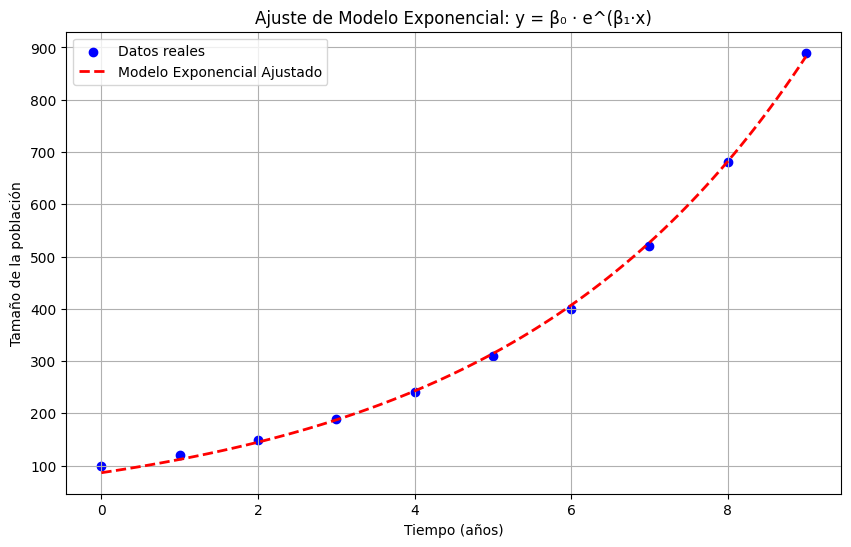

In [ ]:
# Librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Datos simulados (puedes reemplazarlos con los tuyos)
# Supón que estamos modelando crecimiento poblacional
x = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])  # tiempo (años)
y = np.array([100, 120, 150, 190, 240, 310, 400, 520, 680, 890])  # población

# Definir la función del modelo exponencial: y = β₀ * e^(β₁ * x)
def modelo_exponencial(x, beta0, beta1):
    return beta0 * np.exp(beta1 * x)

# Ajustar el modelo a los datos usando curve_fit
parametros, _ = curve_fit(modelo_exponencial, x, y)
beta0, beta1 = parametros
print(f"Parámetros estimados: β₀ = {beta0:.2f}, β₁ = {beta1:.4f}")

# Predicciones
x_pred = np.linspace(min(x), max(x), 100)
y_pred = modelo_exponencial(x_pred, beta0, beta1)

# Visualizar resultados
plt.figure(figsize=(10, 6))
plt.scatter(x, y, color='blue', label='Datos reales')
plt.plot(x_pred, y_pred, color='red', linestyle='--', linewidth=2, label='Modelo Exponencial Ajustado')
plt.xlabel("Tiempo (años)")
plt.ylabel("Tamaño de la población")
plt.title("Ajuste de Modelo Exponencial: y = β₀ · e^(β₁·x)")
plt.legend()
plt.grid(True)
plt.show()
# y=86.46+0.2581*e^(-0.2581*x)
# para x=2 entonces y=86.46+0.2581*e^(-0.2581*2)

Resumen del modelo log-lineal (modelo exponencial):
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.998
Model:                            OLS   Adj. R-squared:                  0.998
Method:                 Least Squares   F-statistic:                     3717.
Date:                Tue, 29 Jul 2025   Prob (F-statistic):           5.82e-12
Time:                        15:40:14   Log-Likelihood:                 20.007
No. Observations:                  10   AIC:                            -36.01
Df Residuals:                       8   BIC:                            -35.41
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------


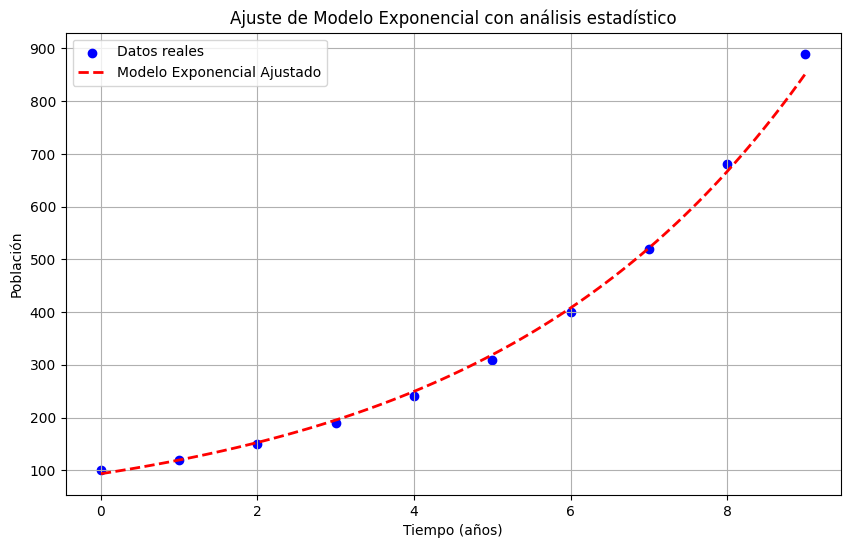

In [ ]:
# Librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Datos simulados: crecimiento poblacional
x = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])           # tiempo
y = np.array([100, 120, 150, 190, 240, 310, 400, 520, 680, 890])  # población

# Transformación logarítmica: ln(y) = ln(β₀) + β₁·x
ln_y = np.log(y)

# Preparar variables para regresión lineal
X = sm.add_constant(x)  # agrega constante para β₀
modelo = sm.OLS(ln_y, X)  # OLS sobre ln(y)
resultados = modelo.fit()

# Resultados
print("Resumen del modelo log-lineal (modelo exponencial):")
print(resultados.summary())

# Predicción del modelo exponencial
beta0_log, beta1 = resultados.params
beta0 = np.exp(beta0_log)
print(f"\nModelo estimado: y = {beta0:.2f} * e^({beta1:.4f} * x)")

# Graficar los datos y el modelo
x_pred = np.linspace(min(x), max(x), 100)
y_pred = beta0 * np.exp(beta1 * x_pred)

plt.figure(figsize=(10, 6))
plt.scatter(x, y, color='blue', label='Datos reales')
plt.plot(x_pred, y_pred, color='red', linestyle='--', linewidth=2, label='Modelo Exponencial Ajustado')
plt.xlabel("Tiempo (años)")
plt.ylabel("Población")
plt.title("Ajuste de Modelo Exponencial con análisis estadístico")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Clase 29/07 Sesión 4 módulo 6
# Clasificación supervisada: Regresión Logística y k-Vecinos + Evaluación
# Paso 1: Importar las librerías necesarias
import pandas as pd                  # Para manejo de datos en tablas
import numpy as np                   # Para cálculos numéricos
from sklearn.datasets import load_iris             # Dataset de ejemplo (flores iris)
from sklearn.model_selection import train_test_split  # Para dividir los datos
from sklearn.preprocessing import StandardScaler     # Para escalar los datos
from sklearn.linear_model import LogisticRegression  # Modelo de regresión logística
from sklearn.neighbors import KNeighborsClassifier   # Modelo k-NN
from sklearn.metrics import confusion_matrix, classification_report  # Métricas de evaluación

# Paso 2: Cargar el dataset Iris (flores)
iris = load_iris()
X = iris.data        # Variables independientes (largo, ancho del pétalo y sépalo)
y = iris.target      # Variable dependiente (tipo de flor: setosa, versicolor, virginica)
print("Clases posibles:", iris.target_names)  # Mostrar los nombres de las clases

# Paso 3: Dividir en conjunto de entrenamiento (70%) y prueba (30%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

# Paso 4: Escalar los datos (muy importante para k-NN y otros modelos)
scaler = StandardScaler()  # Inicializamos el escalador
X_train_scaled = scaler.fit_transform(X_train)  # Ajustamos y transformamos el conjunto de entrenamiento
X_test_scaled = scaler.transform(X_test)        # Solo transformamos el conjunto de prueba

# Paso 5: Crear y entrenar el modelo de Regresión Logística
lr = LogisticRegression()         # Creamos el modelo
lr.fit(X_train_scaled, y_train)   # Entrenamos el modelo con los datos escalados
y_pred_lr = lr.predict(X_test_scaled)  # Hacemos predicciones sobre los datos de prueba

# Paso 6: Crear y entrenar el modelo k-Vecinos más cercanos (k=3)
knn = KNeighborsClassifier(n_neighbors=3)  # Creamos el modelo con k=3 vecinos
knn.fit(X_train_scaled, y_train)           # Entrenamos el modelo
y_pred_knn = knn.predict(X_test_scaled)    # Hacemos predicciones

# Paso 7: Evaluación de ambos modelos con métricas comunes
print(" Evaluación del modelo: Regresión Logística")
print(confusion_matrix(y_test, y_pred_lr))  # Matriz de confusión
print(classification_report(y_test, y_pred_lr, target_names=iris.target_names))  # Precisión, recall y F1-score

print(" Evaluación del modelo: k-Vecinos (k=3)")
print(confusion_matrix(y_test, y_pred_knn))  # Matriz de confusión
print(classification_report(y_test, y_pred_knn, target_names=iris.target_names))  # Métricas del modelo k-NN

Clases posibles: ['setosa' 'versicolor' 'virginica']
 Evaluación del modelo: Regresión Logística
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45

 Evaluación del modelo: k-Vecinos (k=3)
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



Clases posibles: ['setosa' 'versicolor' 'virginica']
Esto indica que la variable objetivo (y) tiene 3 clases:

setosa (clase 0),

versicolor (clase 1),

virginica (clase 2).

Evaluación del modelo: Regresión Logística
Matriz de confusión
plaintext
Copiar
Editar
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]
Cada fila representa la clase verdadera y cada columna la predicción del modelo.

Interpretación:

El modelo predijo correctamente las 19 muestras de setosa, las 13 de versicolor y las 13 de virginica.

No hubo falsos positivos ni falsos negativos: la diagonal principal tiene todos los valores, y los demás son cero → predicción perfecta.

Métricas de evaluación
plaintext
Copiar
Editar
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45
Interpretación de métricas (idénticas para todas las clases):

Precision (precisión): Proporción de predicciones correctas entre las que el modelo dijo que eran de esa clase.

Recall (sensibilidad): Proporción de elementos de esa clase que el modelo identificó correctamente.

F1-score: Promedio armónico entre precisión y recall (ideal si ambos son altos).

Accuracy (exactitud): Proporción total de aciertos → 1.00 = 100% correcto.

Macro avg: Promedio de las métricas de todas las clases (sin ponderar por cantidad de datos).

Weighted avg: Promedio ponderado por el número de muestras de cada clase.

Evaluación del modelo: k-Vecinos (k=3)
La matriz de confusión y las métricas son idénticas a las de la regresión logística:

plaintext
Copiar
Editar
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]
Mismo análisis: el modelo de k-NN también clasificó perfectamente todas las muestras del conjunto de prueba.

Conclusión general
Ambos modelos tienen:

Exactitud del 100%, lo cual es poco común en datasets reales.

Esto ocurre porque el dataset de Iris es limpio, pequeño, y tiene clases bien separadas.

En la práctica, deberías usar validación cruzada para confirmar que este rendimiento no es por suerte o sobreajuste.